# Processing Inhibitor Data

____

In [1]:
from pathlib import Path
current_dir = Path().resolve()
from microlive.imports import *
from microlive import microscopy as mi
main_dir = Path().resolve().parent
one_drive_dir = mi.Utilities.get_one_drive_dir()
import inhibitors as INH

## Data Configuration
___

In [2]:
# Loading data
        #RMS External Drive Location:    'E:/Co-translational folding (CoF) paper/Fig 3_Har/non pb'
        #Ning Zhao OneDrive Location:    '...General - Zhao (NZ) Lab\Zhao lab shared folder\Our papers\co-translational folding paper\Fig 3_Har\Fig 3_Har analysis'


# ── Data Path ─────────────────────────────────────────────
data_dir = one_drive_dir / 'General - Zhao (NZ) Lab' / 'Zhao lab shared folder' / 'Our papers' / 'co-translational folding paper' / 'Fig 2' / 'Fig 2_4xGFP har analysis'#Onedrive
# data_dir = Path(r'E:/Co-translational folding (CoF) paper/Fig 3_Har/non pb') #RMS External Drive

#data_dir = 'General - Zhao (NZ) Lab\Zhao lab shared folder\Our papers\co-translational folding paper\Fig 2\Fig 2_4xGFP har analysis'
 
# elongation rates
def elongation_rates (gene_length,dwell_time ):
    ke = gene_length/ dwell_time
    return np.round(ke,3)

# ── Processing Parameters ─────────────────────────────────
inhibitor_frame_index = 4  # 0-indexed: frame when treatment was applied
use_sem = True
show_summary = True
show_individual_trajectories = False
max_percentage_threshold_after_treatment = None #0.5
threshold_percentage_for_runoff = 0.1
use_sigmoidal_fit = True
# ── Plotting Parameters ───────────────────────────────────
figsize = (5, 4)
ylims = (-0.1, 1.3)
xlims = (-5, 45.5)                              # limits needs to be set to include more than the fit_end_idx frames for the x-axis
fit_start_idx=inhibitor_frame_index          # int – fit range start (default: inh frame)
#fit_end_idx=last frame                               # int – fit range end (default: last frame) for linear use ~15
results_folder = Path('temp') #Path('E:/Co-translational folding (CoF) paper/Fig 3_Har graphs')  # Set to a Path to save plots
#results_folder.mkdir(parents=True, exist_ok=True)


In [3]:
# parameters for linears fits 
r2_threshold = 0.95   # must match what you passed to plot_inhibitor
drug_diffusion_time_min = 1
frame_interval_sec = 60
# gene length
g_length = 1826  # gene length total
half_tag = 167   # gene length total
g_length_effective = g_length-half_tag # gene_length_without_half_tag

## HA Channel (pRS027; 4xGFPfast)
___

── Linear Fit (4, 11) ──
  a (slope): -0.1204
  b (intercept): 0.9761
  Iss (baseline): 0.1819
  a_err: 0.0032
  b_err: 0.0149
  t½:      3.30 min
  τ_runoff (2×t½): 6.60 min
  ke:      4.9411 aa/s
  χ²_red:  4.1028  (dof=6)
  R²:      0.971  (n=8)


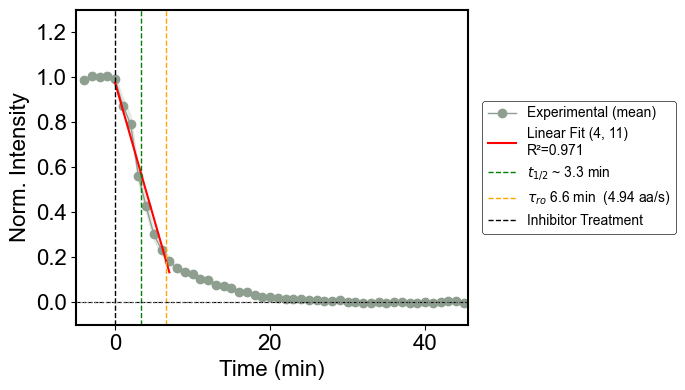

responding_indices_pRS027_HA: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
number of responding trajectories for pRS027_HA: 26


In [4]:
substring_in_data_dir = 'pRS027'
selected_field = 'spot_int_ch_0'
plot_name = 'pRS027-only_HA_fit'
 
responding_indices_pRS027_HA, frames_pRS027_HA, intensities_pRS027_HA, _, _, _, _, _ = INH.process_inhibitor_data(
    data_dir, inhibitor_frame_index, substring_in_data_dir, selected_field,
    use_sem, show_summary, max_percentage_threshold_after_treatment,remove_frame_at_inhibitor_application=False,frame_interval_sec = frame_interval_sec,
)
 
 
results=INH.plot_inhibitor(
    frames_pRS027_HA,                                 # np.ndarray – time array
    intensities_pRS027_HA,                            # np.ndarray – 2D (cells × frames)
    inhibitor_frame_index,                            # int – treatment frame index
    results_folder=results_folder,                    # Path – save location
    plot_name=plot_name,                              # str – filename suffix
    responding_indices=responding_indices_pRS027_HA,  # list – which cells to include
    figsize=figsize,                                  # tuple
    use_sem=True,                                     # bool – SEM vs SD for error band
    show_individual_trajectories=False,               # bool – gray individual traces
    ylims=ylims,                                      # tuple – y-axis limits
    xlims=xlims,                                      # tuple – x-axis limits
    y_label='Norm. Intensity',                        # str
    treatment_label='Inhibitor',                      # str – label for treatment line
    show_treatment_line=True,                         # bool – vertical line at t=0
    show_fit=True,                                    # bool – overlay fitted curve
    show_runoff_time=True,                            # bool – draw t½ and τ_runoff lines
    runoff_fraction=0.9,                              # float – threshold for run-off (0.95 = 95%)
    remove_background_intensity=True,                 # subtract background & rescale to 0-1
    background_frames=10,                             # use last 10 frames within xlims window
    show_background_line=True,                        # dashed line at background level
    show_zero_y_axis=True,                            # dashed line at y = 0
    colors='#8E9E8F',
    # parameters for linear fits
    fit_model='linear',                               # 'linear'|'exponential'|'heaviside'|None
    fit_start_idx=fit_start_idx,                      # int – fit range start (default: inh frame)
    gene_length_effective=g_length_effective,
    drug_diffusion_time_min = drug_diffusion_time_min,
    fit_end_idx=11,                                  # int – fit range end (fast = 11; slow = 17)
    #fit_end_range = (8,15),                           # range to fit data.
    r2_threshold = r2_threshold,                      # threshold for best fit selection
    
    
)
 
print("responding_indices_pRS027_HA:", responding_indices_pRS027_HA)
print("number of responding trajectories for pRS027_HA:", len(responding_indices_pRS027_HA))
 
 
# Access each dataset by index
#print('run-off time dataset 0:', results['t_runoff'])


### 4xGFPfast Ke

## HA Channel (pRS032; 4xGFPslow)
___

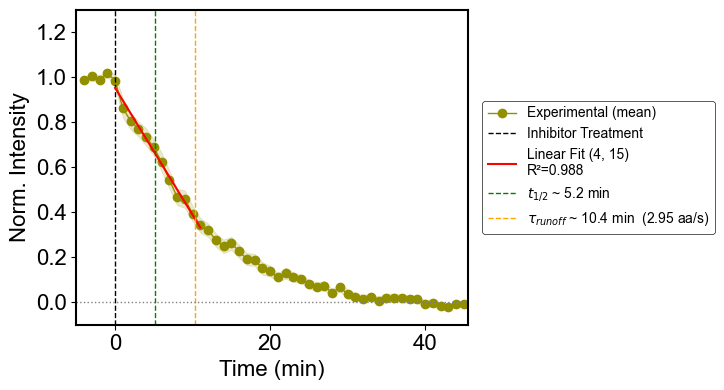

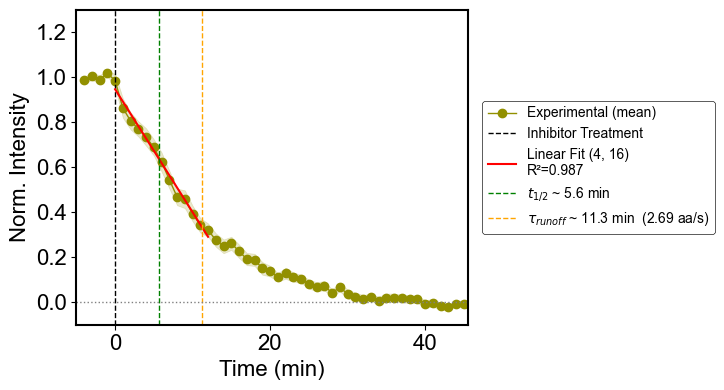

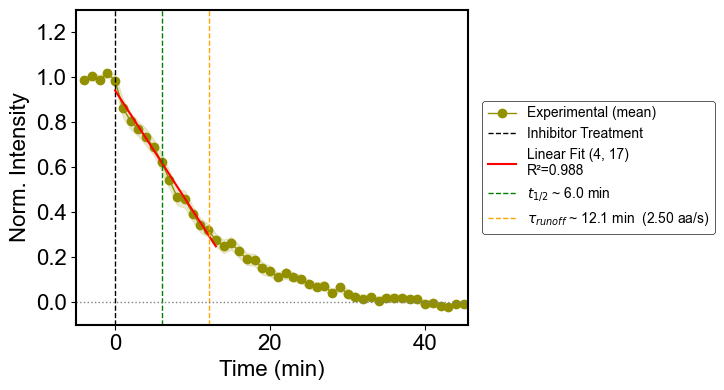

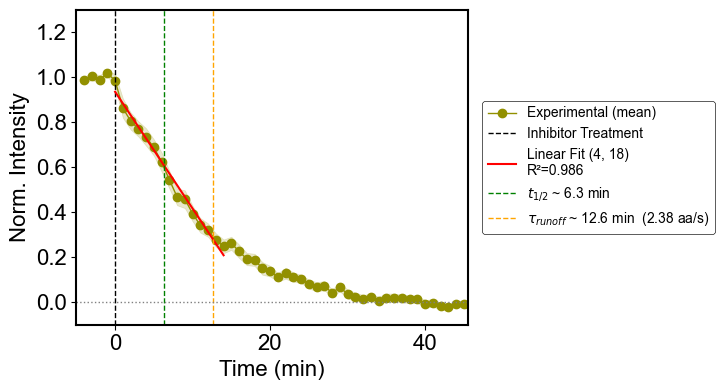

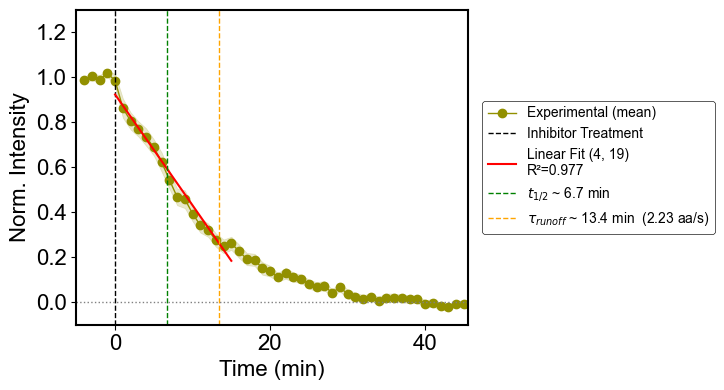

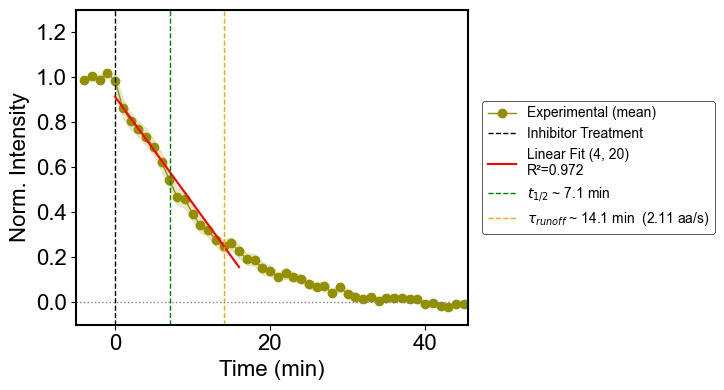

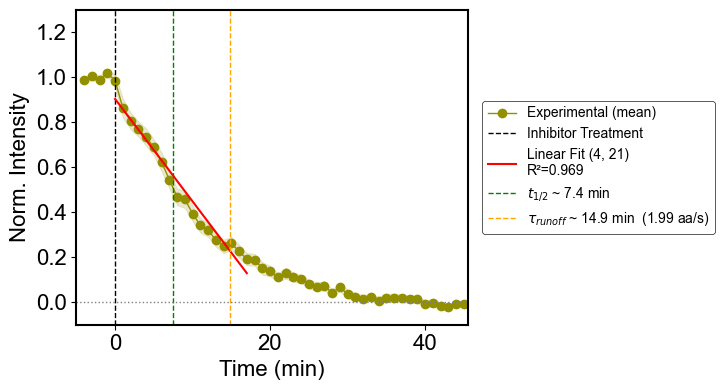

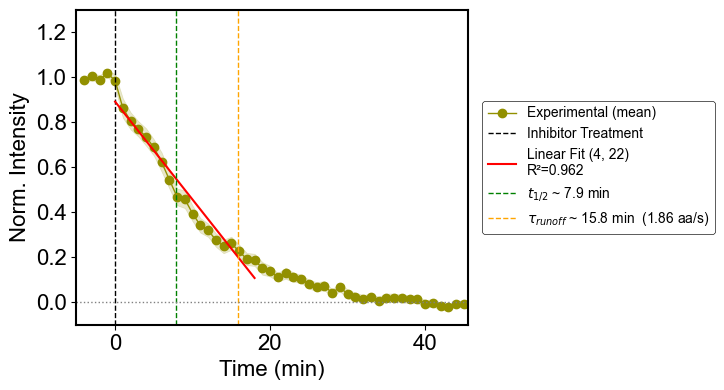

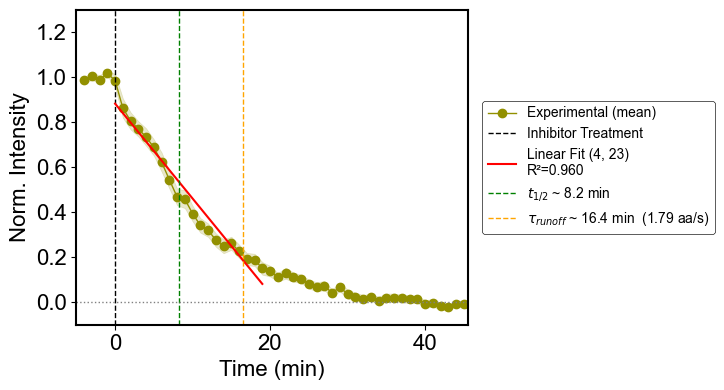

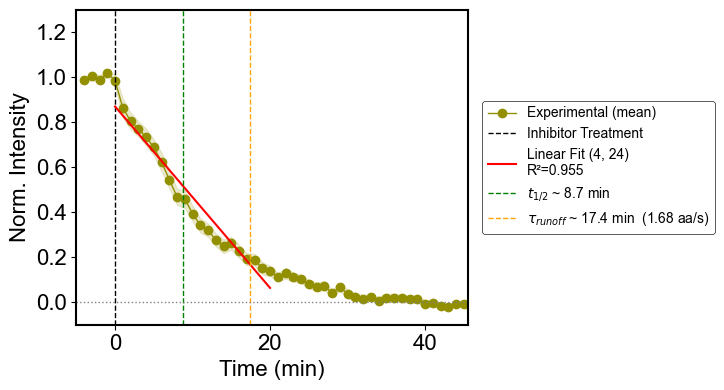

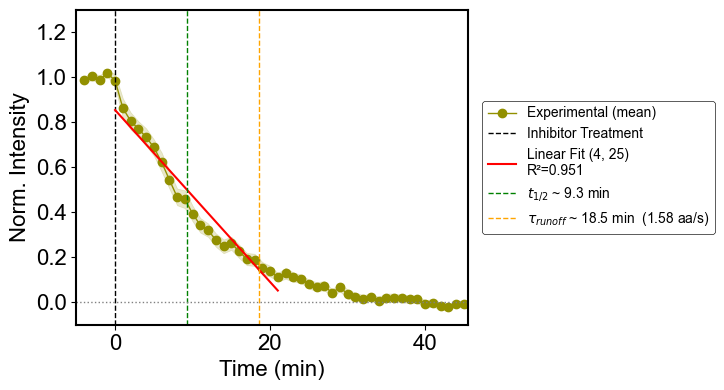

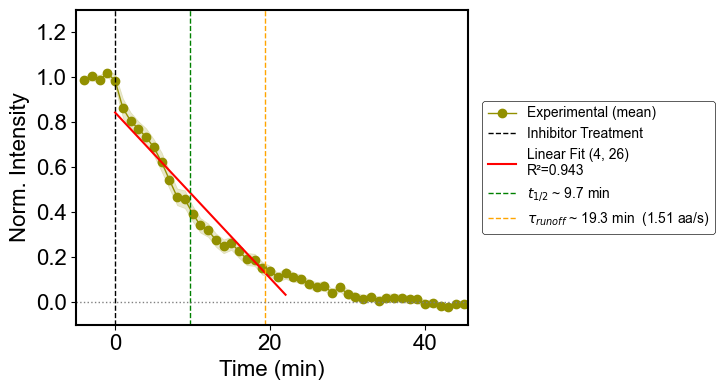

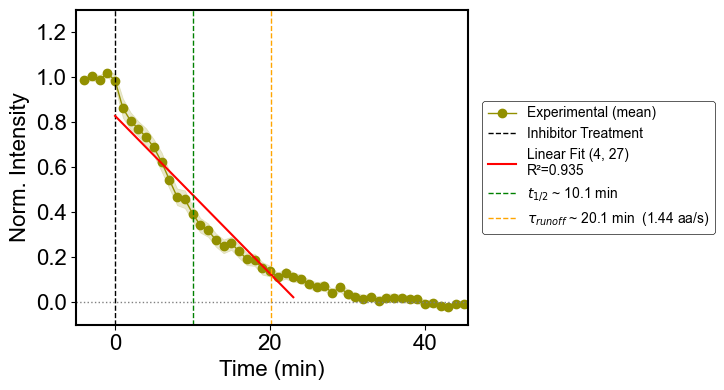

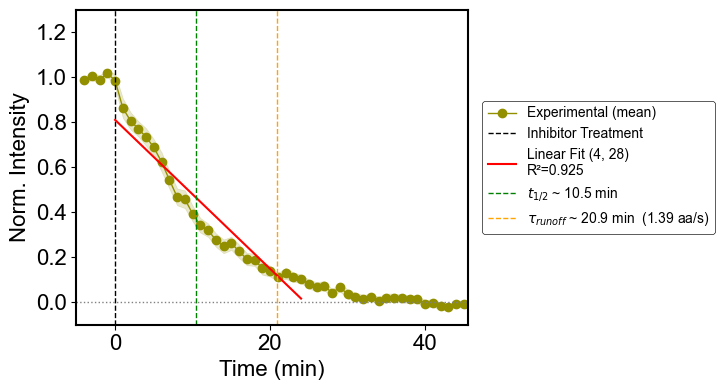


────────────────────────────────────────────────────────────────────────────
 Fit Comparison  (start=4, model=linear, R²≥0.95)
────────────────────────────────────────────────────────────────────────────
   #  end_idx  n_pts   k    χ²_red       R²      ke(aa/s)
────────────────────────────────────────────────────────────────────────────
   1       15     12   2    0.4244    0.988         2.954
   2       16     13   2    0.5235    0.987         2.694
   3       17     14   2    0.5865    0.988         2.500
   4       18     15   2    0.7138    0.986         2.385
   5       19     16   2    1.3477    0.977         2.227
   6       20     17   2    1.7411    0.972         2.110
   7       21     18   2    2.0714    0.969         1.995
   8       22     19   2    2.6291    0.962         1.864
   9       23     20   2    2.8997    0.960         1.790
  10       24     21   2    3.4329    0.955         1.683
  11       25     22   2    4.0356    0.951         1.579  ← RECOMMENDED
  12   

In [5]:
substring_in_data_dir = 'pRS032'
selected_field = 'spot_int_ch_0'
plot_name = 'pRS032-only_HA_fit'
 
responding_indices_pRS032_HA, frames_pRS032_HA, intensities_pRS032_HA, _, _, _, _, _ = INH.process_inhibitor_data(
    data_dir, inhibitor_frame_index, substring_in_data_dir, selected_field,
    use_sem, show_summary, max_percentage_threshold_after_treatment,remove_frame_at_inhibitor_application=False,frame_interval_sec = frame_interval_sec,
)

 
 
results=INH.plot_inhibitor(
    frames_pRS032_HA,                                 # np.ndarray – time array
    intensities_pRS032_HA,                            # np.ndarray – 2D (cells × frames)
    inhibitor_frame_index,                            # int – treatment frame index
    results_folder=results_folder,                    # Path – save location
    plot_name=plot_name,                              # str – filename suffix
    responding_indices=responding_indices_pRS032_HA,  # list – which cells to include
    figsize=figsize,                                  # tuple
    use_sem=True,                                     # bool – SEM vs SD for error band
    show_individual_trajectories=False,               # bool – gray individual traces
    ylims=ylims,                                      # tuple – y-axis limits
    xlims=xlims,                                      # tuple – x-axis limits
    y_label='Norm. Intensity',                        # str
    treatment_label='Inhibitor',                      # str – label for treatment line
    show_treatment_line=True,                         # bool – vertical line at t=0
    show_fit=True,                                    # bool – overlay fitted curve
    show_runoff_time=True,                            # bool – draw t½ and τ_runoff lines
    runoff_fraction=0.9,                              # float – threshold for run-off (0.95 = 95%)
    remove_background_intensity=True,                 # subtract background & rescale to 0-1
    background_frames=10,                             # use last 10 frames within xlims window
    show_background_line=True,                        # dashed line at background level
    show_zero_y_axis=True,                            # dashed line at y = 0
    colors='#929000',
    # parameters for linear fits
    fit_model='linear',                               # 'linear'|'exponential'|'heaviside'|None
    fit_start_idx=fit_start_idx,                      # int – fit range start (default: inh frame)
    #fit_end_idx=17,                                  # int – fit range end (fast = 11; slow = 17)
    fit_end_range = (15,28),                          # range to fit data.
    r2_threshold = r2_threshold,                      # threshold for best fit selection
    gene_length_effective=g_length_effective,
    drug_diffusion_time_min = drug_diffusion_time_min,
)
 
print("responding_indices_pRS032_HA:", responding_indices_pRS032_HA)
print("number of responding trajectories for pRS032_HA:", len(responding_indices_pRS032_HA))

 
# Access each dataset by index
#print('run-off time dataset 0:', results['t_runoff'])

### 4xGFPslow Ke

## Multi-Reporter Comparison
___

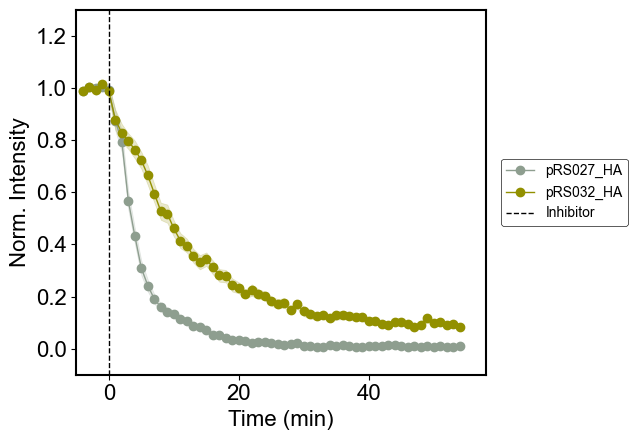

responding_indices_pRS027_HA: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
number of responding trajectories for pRS027_HA: 26
responding_indices_pRS032_HA: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
number of responding trajectories for pRS032_HA: 28


In [6]:
INH.plot_multiple_inhibitors(
    [frames_pRS027_HA, frames_pRS032_HA,],
    [intensities_pRS027_HA, intensities_pRS032_HA],
    inhibitor_frame_index,
    responding_indices_list=[responding_indices_pRS027_HA, responding_indices_pRS032_HA],
    colors=['#8E9E8F', '#929000'],
    legend_labels=['pRS027_HA', 'pRS032_HA'],
    plot_name='fast vs slow',
    #threshold_percentage_for_runoff=-0.4,
    ylims=ylims,
    xlims=(-5, 58),
    figsize=(6.5, 4.5),
    use_sem=True,
    show_individual_trajectories=show_individual_trajectories,
    show_treatment_line=True,                        # bool – vertical line at t=0
    show_runoff_time=False,                           # bool – draw t½ and τ_runoff lines
    results_folder=results_folder,
)

print("responding_indices_pRS027_HA:", responding_indices_pRS027_HA)
print("number of responding trajectories for pRS027_HA:", len(responding_indices_pRS027_HA))
print("responding_indices_pRS032_HA:", responding_indices_pRS032_HA)
print("number of responding trajectories for pRS032_HA:", len(responding_indices_pRS032_HA))